In [29]:
PRODUCTION_QUALITY = False

import ipdb
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import seaborn as sns
import pandas as pd
import os
import re
import warnings

from labellines import labelLines

OUTPUT_DIR='../00-experiment-batch-size-variation/images'
os.makedirs(OUTPUT_DIR, exist_ok=True) # make sure it exists

plt.style.use(['science', 'bright'])

dpi = 300 if PRODUCTION_QUALITY else 100

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 9,
    'font.family': 'serif',
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'figure.constrained_layout.use': True,
    'legend.frameon': True,
    'savefig.dpi': dpi,
})

# width of the thesis in points
WIDTH = 441.01775

# image saving format
IMG_FORMAT = 'pdf'

In [30]:
def set_size(width_pt, fraction=1, subplots=(1, 1), y_scale=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    
    if y_scale:
        fig_height_in = fig_height_in * y_scale

    return (fig_width_in, fig_height_in)

In [31]:
def get_figure(subplots, fraction=1.0, y_scale=False):
    figsize = set_size(WIDTH, fraction=fraction, subplots=subplots, y_scale=y_scale)
    fig, axes = plt.subplots(subplots[0], subplots[1], figsize=figsize, constrained_layout=True)

    return fig, axes

In [32]:
def read_json_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [33]:
def prepare_data(data):
    records = []
    for experiment_id, experiment_details in data.items():
        # Extracting values from the JSON structure
        subset_size = experiment_details['configuration']['subset_size']
        batch_size = experiment_details['hyperparameters']['batch_size']
        
        # Handling the full batch size case
        if batch_size == -1:
            full_batch_size = 5000 if subset_size == 0.1 else 50000
            batch_size = full_batch_size
            
        learning_rate = experiment_details['best_params']['learning_rate']
        max_grad_norm = experiment_details['best_params']['max_grad_norm']
        epochs = experiment_details['best_params']['epochs']

        record = {
            'model_name': experiment_details['configuration']['model_name'],
            'dataset_name': experiment_details['configuration']['dataset_name'],
            'subset_size': subset_size,
            'epsilon': experiment_details['hyperparameters']['target_epsilon'],
            'batch_size': batch_size,
            'accuracy': float(experiment_details['best_value']),
            'learning_rate': learning_rate,
            'max_grad_norm': max_grad_norm,
            'epochs'
        }
        records.append(record)

    return pd.DataFrame(records)

# Accuracy comparison

In [34]:
def plot_accuracy_trends(prepared_data, output_dir=None):
    # Ensure data is sorted for consistent color mapping
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'batch_size'], inplace=True)

    # Get unique combinations of model, dataset, and subset size
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size'])

    for (model, dataset, subset), group in groups:
        fig, ax = get_figure((1, 1))

        # Plotting for each epsilon within the group
        grouped_by_epsilon = group.groupby('epsilon')
        for epsilon, eps_data in grouped_by_epsilon:
            eps_data = eps_data.sort_values(by='batch_size')
            ax.plot(eps_data['batch_size'], eps_data['accuracy'], label=f'$\epsilon={epsilon}$', marker='o')
        
        ax.set_title(f'Accuracy Trends for {model} on {dataset} ({int(subset*100)}\% Subset)')
        ax.set_xlabel('Batch Size')
        ax.set_ylabel('Accuracy')
        ax.set_ylim([0, 1])
        ax.set_xscale('log')  # Use log scale for batch size

        unique_batch_sizes = np.unique(group['batch_size'])
        ax.set_xticks(unique_batch_sizes)
        ax.set_xticklabels(unique_batch_sizes, rotation=45)

        ax.legend()
        ax.grid(True)
        
        if len(grouped_by_epsilon) == 6:
            xvals = [320, 450, 600, 900, 1500, 2500]
        else:
            xvals = [2048]

        lines = plt.gca().get_lines()
        labelLines(lines, align=True, xvals=xvals)

        plt.show()

In [35]:
def plot():
    file_path = '../00-experiment-batch-size-variation/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_accuracy_trends(processed_data, output_dir=OUTPUT_DIR)

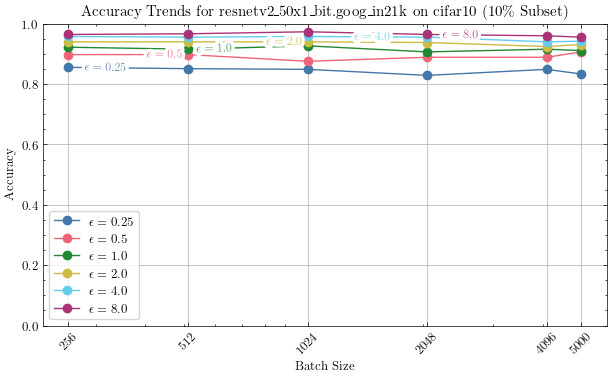

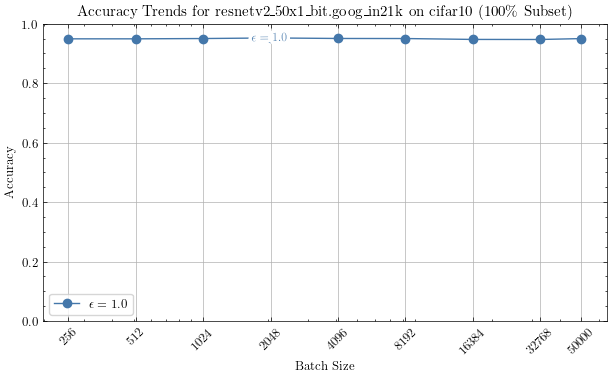

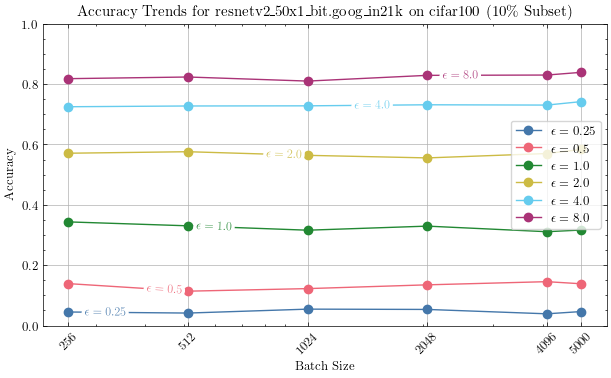

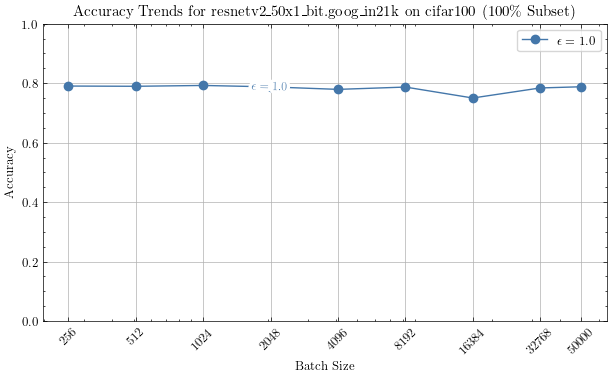

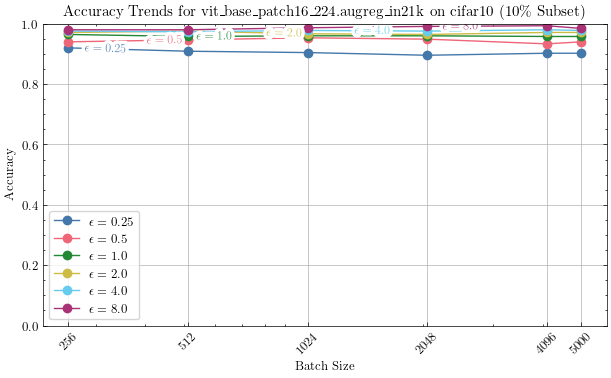

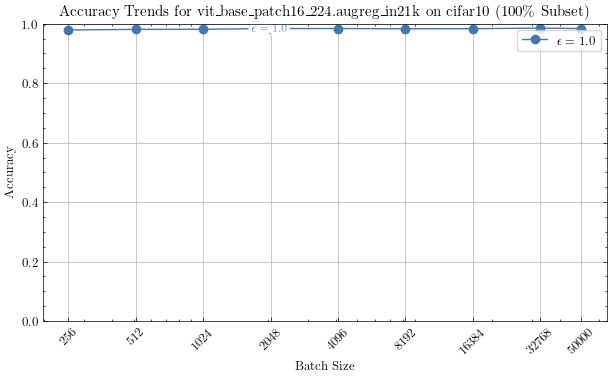

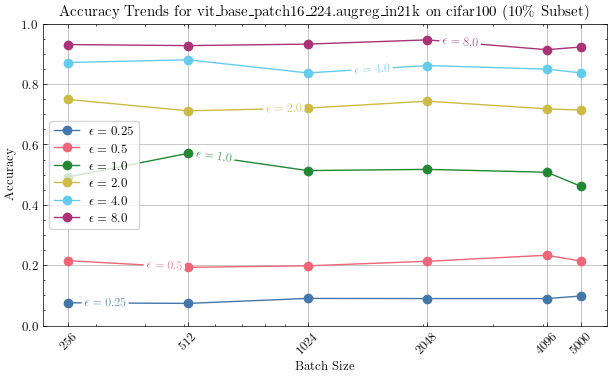

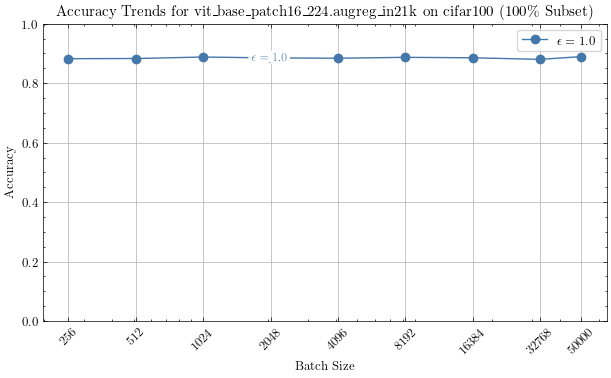

In [36]:
plot()

# Batch size vs learning rate

In [37]:
def plot_learning_rate_trends(prepared_data, output_dir=None):
    # Ensure data is sorted for consistent color mapping
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'batch_size'], inplace=True)

    # Get unique combinations of model, dataset, and subset size
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size'])

    for (model, dataset, subset), group in groups:
        fig, ax = get_figure((1, 1))
        # Plotting for each epsilon within the group
        grouped_by_epsilon = group.groupby('epsilon')
        for epsilon, eps_data in grouped_by_epsilon:
            eps_data = eps_data.sort_values(by='batch_size')
            ax.plot(eps_data['batch_size'], eps_data['learning_rate'], label=f'$\epsilon={epsilon}$', marker='o')
        
        ax.set_title(f'Learning Rate Trends for {model} on {dataset} ({int(subset*100)}\% Subset)')
        ax.set_xlabel('Batch Size')
        ax.set_ylabel('Learning Rate')
        ax.set_xscale('log')  # Use log scale for batch size
        ax.set_ylim([0, 0.011])

        unique_batch_sizes = np.unique(group['batch_size'])
        ax.set_xticks(unique_batch_sizes)
        ax.set_xticklabels(unique_batch_sizes, rotation=45)
        ax.legend()

        ax.grid(True)

        if len(grouped_by_epsilon) == 6:
            xvals = [320, 450, 600, 900, 1500, 2500]
        else:
            xvals = [2048]

        lines = plt.gca().get_lines()
        labelLines(lines, align=True, xvals=xvals)

        plt.show()

In [38]:
def plot():
    file_path = '../00-experiment-batch-size-variation/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_learning_rate_trends(processed_data, output_dir=OUTPUT_DIR)

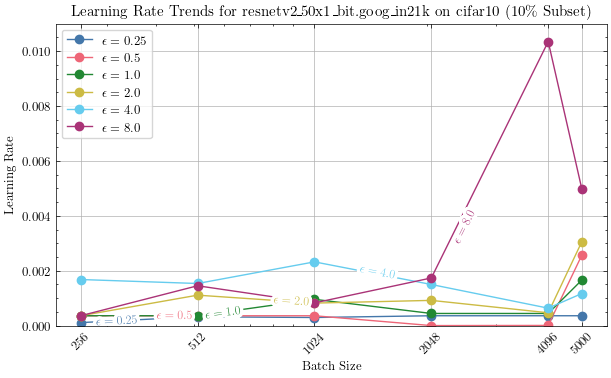

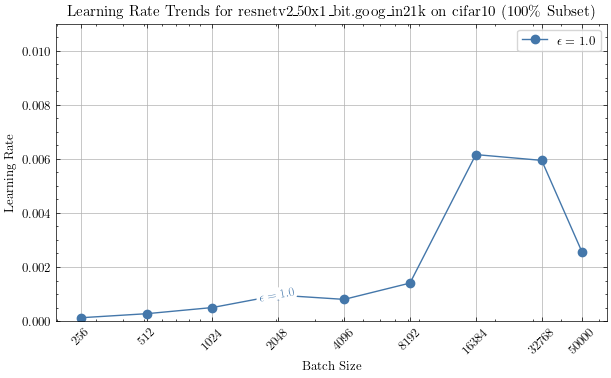

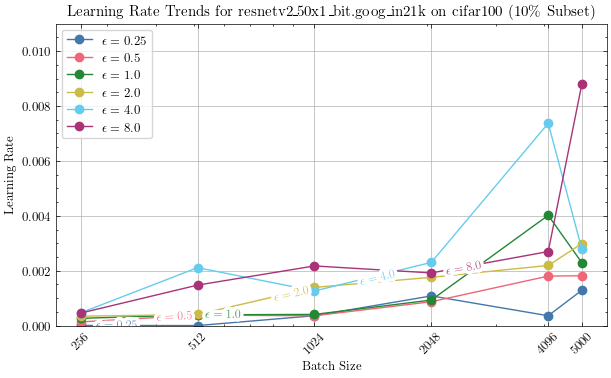

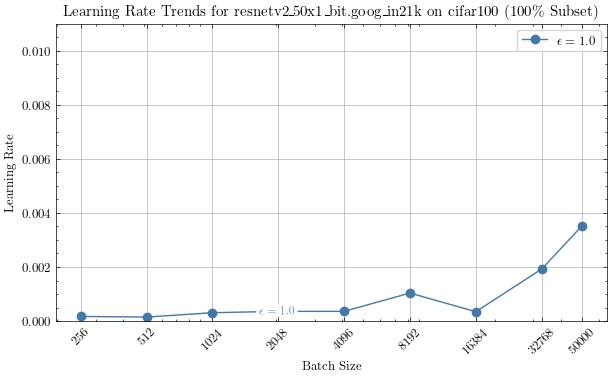

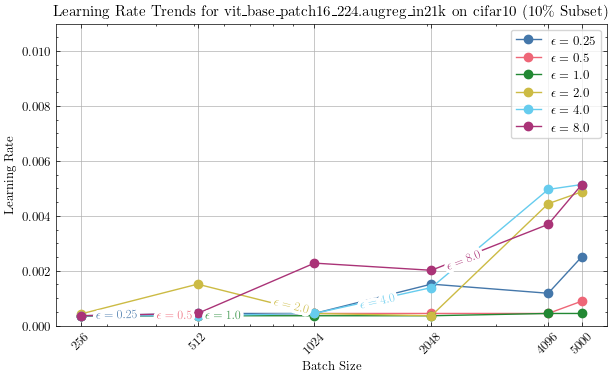

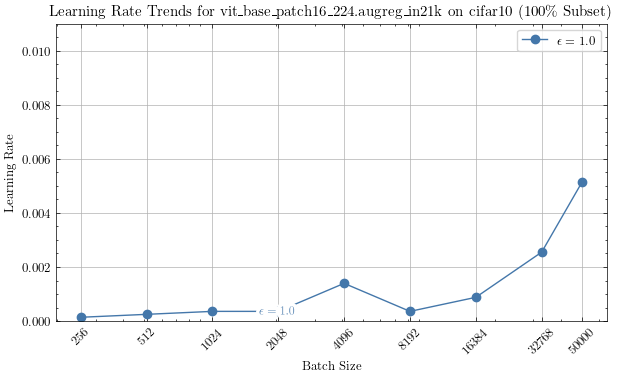

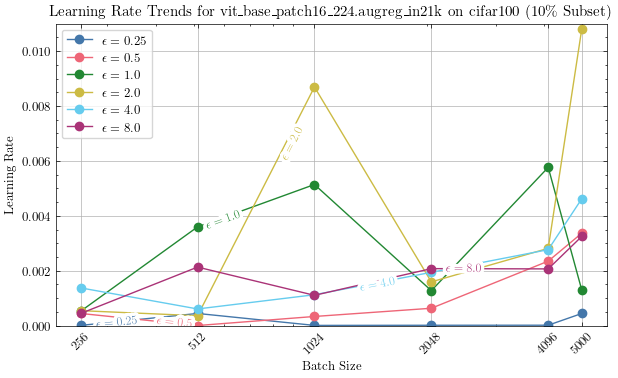

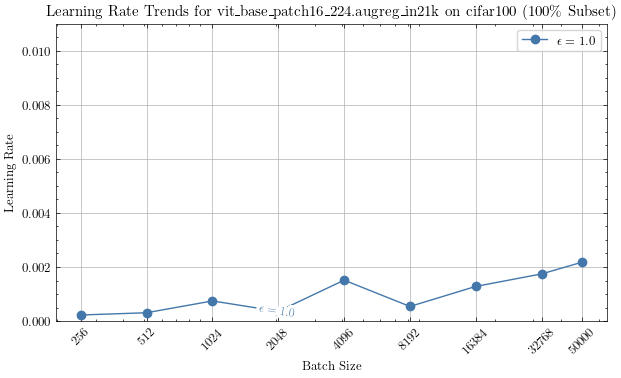

In [39]:
plot()

# Batch size vs Maximum gradient norm

In [33]:
def plot_max_grad_norm_trends(prepared_data, output_dir=None):
    # Ensure data is sorted for consistent color mapping
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'batch_size'], inplace=True)

    # Get unique combinations of model, dataset, and subset size
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size'])

    for (model, dataset, subset), group in groups:
        fig, ax = get_figure((1, 1))

        # Plotting for each epsilon within the group
        grouped_by_epsilon = group.groupby('epsilon')
        for epsilon, eps_data in grouped_by_epsilon:
            # Sorting by batch size for proper line plotting
            eps_data = eps_data.sort_values(by='batch_size')

            # Adding dots on observations with marker='o'
            ax.plot(eps_data['batch_size'], eps_data['max_grad_norm'], label=f'$\epsilon={epsilon}$', marker='o')
        
        ax.set_title(f'Maximum Gradient Norm Trends for {model} on {dataset} ({int(subset*100)}\% Subset)')
        ax.set_xlabel('Batch Size')
        ax.set_ylabel('Maxium gradient norm')
        ax.set_xscale('log')  # Use log scale for batch size
        ax.set_ylim([0, 11])

        unique_batch_sizes = np.unique(group['batch_size'])
        ax.set_xticks(unique_batch_sizes)
        ax.set_xticklabels(unique_batch_sizes, rotation=45)
        ax.legend()

        ax.grid(True)

        if len(grouped_by_epsilon) == 6:
            xvals = [320, 450, 600, 900, 1500, 2500]
        else:
            xvals = [2048]

        lines = plt.gca().get_lines()
        labelLines(lines, align=True, xvals=xvals)

        plt.show()

In [34]:
def plot():
    file_path = '../00-experiment-batch-size-variation/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_max_grad_norm_trends(processed_data, output_dir=OUTPUT_DIR)

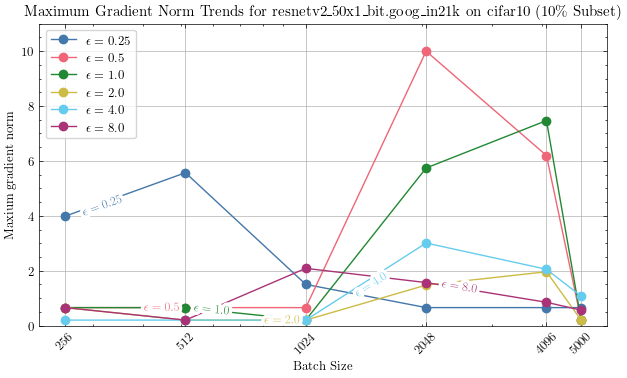

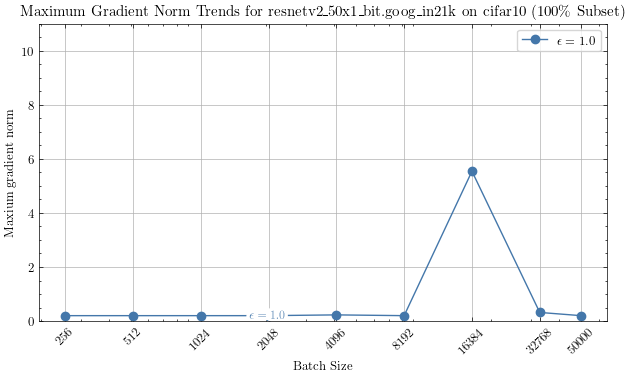

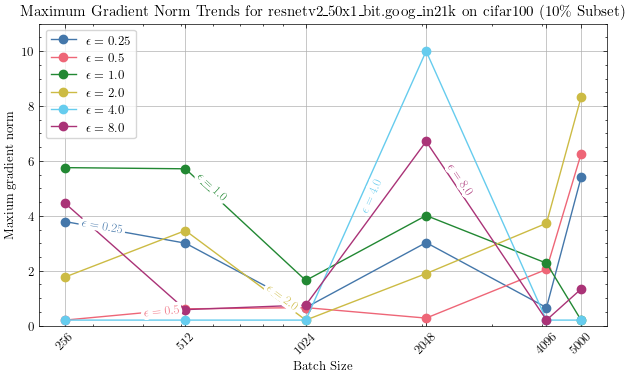

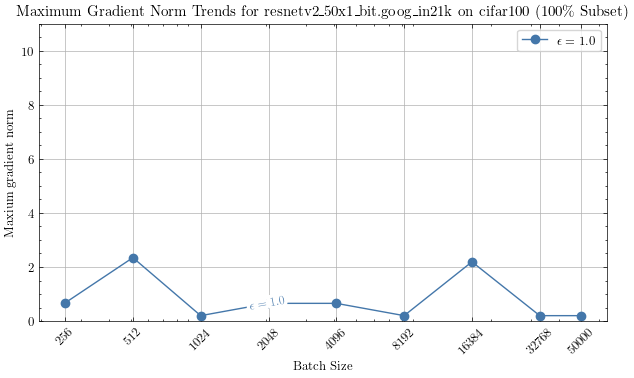

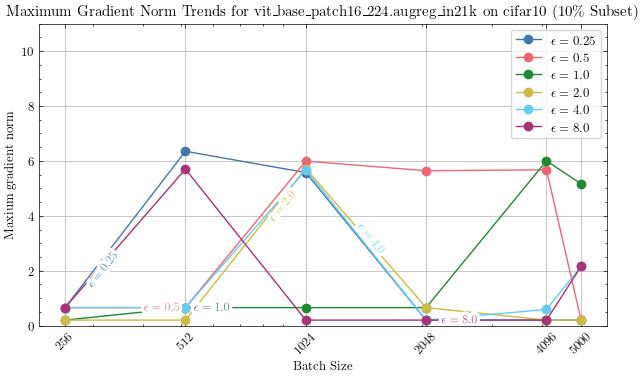

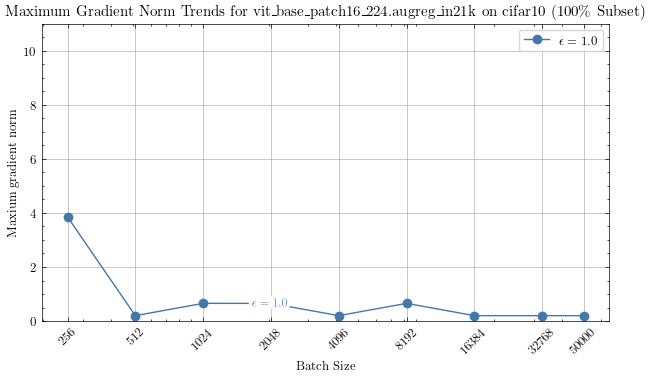

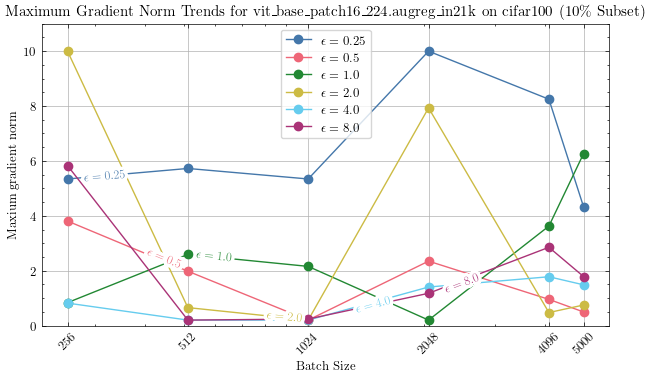

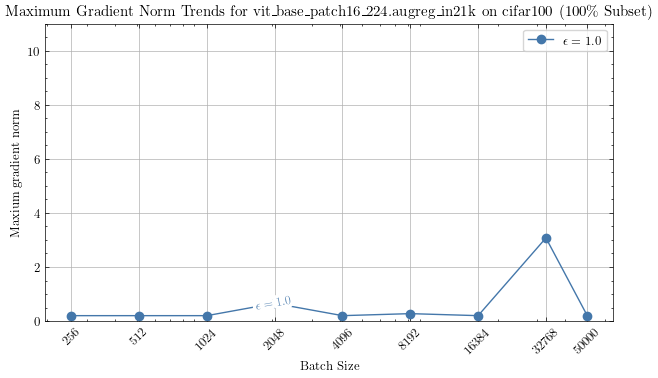

In [35]:
plot()

# Batch size vs Epochs

In [40]:
def plot_epoch_trends(prepared_data, output_dir=None):
    # Ensure data is sorted for consistent color mapping
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'batch_size'], inplace=True)

    # Get unique combinations of model, dataset, and subset size
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size'])

    for (model, dataset, subset), group in groups:
        fig, ax = get_figure((1, 1))

        # Plotting for each epsilon within the group
        grouped_by_epsilon = group.groupby('epsilon')
        for epsilon, eps_data in grouped_by_epsilon:
            # Sorting by batch size for proper line plotting
            eps_data = eps_data.sort_values(by='batch_size')

            # Adding dots on observations with marker='o'
            ax.plot(eps_data['batch_size'], eps_data['epochs'], label=f'$\epsilon={epsilon}$', marker='o')
        
        ax.set_title(f'Epoch Trends for {model} on {dataset} ({int(subset*100)}\% Subset)')
        ax.set_xlabel('Batch Size')
        ax.set_ylabel('Maxium gradient norm')
        ax.set_xscale('log')  # Use log scale for batch size
        ax.set_ylim([0, 11])

        unique_batch_sizes = np.unique(group['batch_size'])
        ax.set_xticks(unique_batch_sizes)
        ax.set_xticklabels(unique_batch_sizes, rotation=45)
        ax.legend()

        ax.grid(True)

        if len(grouped_by_epsilon) == 6:
            xvals = [320, 450, 600, 900, 1500, 2500]
        else:
            xvals = [2048]

        lines = plt.gca().get_lines()
        labelLines(lines, align=True, xvals=xvals)

        plt.show()

In [41]:
def plot():
    file_path = '../00-experiment-batch-size-variation/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_epoch_trends(processed_data, output_dir=OUTPUT_DIR)

KeyError: 'epochs'

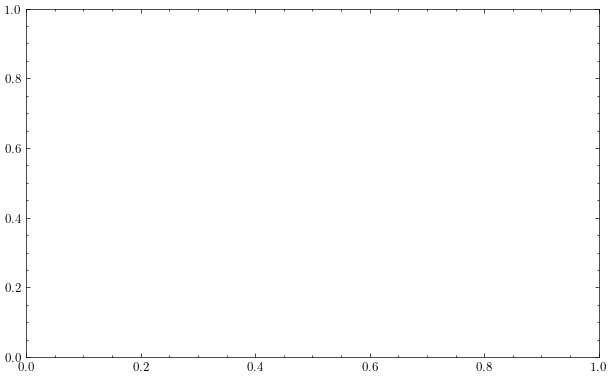

In [42]:
plot()